# Sampling Strategies and Microbatching

The batch sampling strategy determines the privacy amplification
guarantee. This notebook compares Poisson and truncated Poisson
sampling (truncation caps batch size but is no better for privacy at the
same rate), shows how to match the sampler to the correct accounting
method, and demonstrates microbatching for memory-efficient training.

**Prerequisites:** [DP-SGD Training tutorial](dp_sgd_training.ipynb).

**Components exercised:** `PoissonSampler` (plain + truncated via ``truncated_batch_size``),
`clipped_grad` with `microbatch_size`, `dpsgd_acc.poisson` (plain and truncated forms).

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

import opaque.accounting as acc
import opaque.dpsgd.accounting as dpsgd_acc
from opaque.dpsgd.clipping import clipped_grad
from opaque.dpsgd.noise import gaussian_noise
from opaque.dpsgd.sampling import PoissonSampler
from opaque.functional import make_functional
from opaque.random import key

torch.manual_seed(42)
np.random.seed(42)

## Dataset and model

In [2]:
dataset_size = 1000
X = torch.randn(dataset_size, 10)
y = (X[:, 0] > 0).float()
dataset = TensorDataset(X, y)


class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(10, 32)
        self.fc2 = nn.Linear(32, 1)

    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x))).squeeze(-1)

## Comparing batch size distributions

Each sampler produces a different distribution of batch sizes.

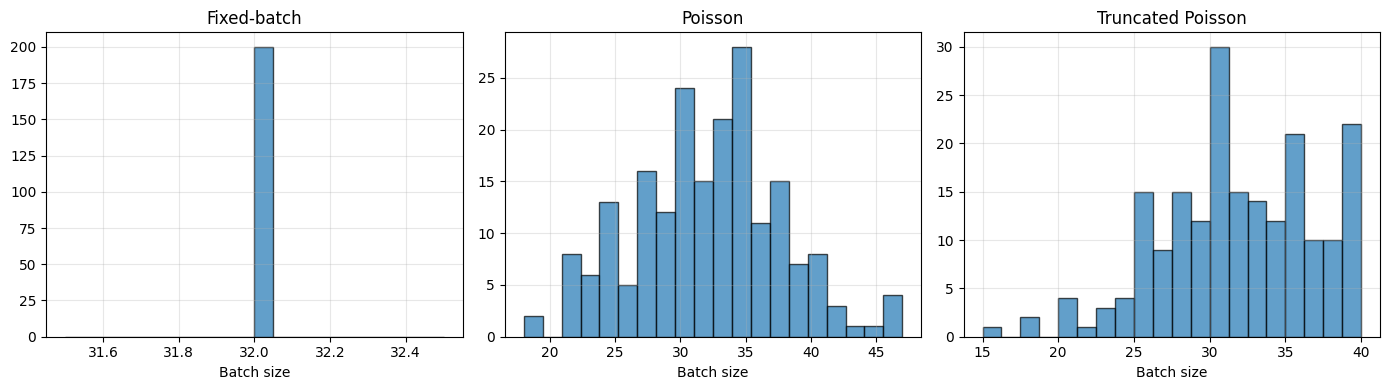

Poisson   -- mean: 32.0, std: 5.5, max: 47
Truncated -- mean: 31.8, std: 5.1, max: 40


In [3]:
batch_size = 32
sample_rate = batch_size / dataset_size
max_batch = 40
n_samples = 200

# Fixed-batch
fixed_sizes = [batch_size] * n_samples

# Poisson
poisson_sampler = PoissonSampler(
    dataset,
    sample_rate=sample_rate,
    n_steps=n_samples,
    key=key(42),
)
poisson_sizes = [len(batch) for batch in poisson_sampler]

# Truncated Poisson
trunc_sampler = PoissonSampler(
    dataset,
    sample_rate=sample_rate,
    truncated_batch_size=max_batch,
    n_steps=n_samples,
    key=key(43),
)
trunc_sizes = [len(batch) for batch in trunc_sampler]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, sizes, title in zip(
    axes,
    [fixed_sizes, poisson_sizes, trunc_sizes],
    ["Fixed-batch", "Poisson", "Truncated Poisson"],
):
    ax.hist(sizes, bins=20, edgecolor="black", alpha=0.7)
    ax.set_xlabel("Batch size")
    ax.set_title(title)
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(
    f"Poisson   -- mean: {np.mean(poisson_sizes):.1f}, std: {np.std(poisson_sizes):.1f}, "
    f"max: {max(poisson_sizes)}"
)
print(
    f"Truncated -- mean: {np.mean(trunc_sizes):.1f}, std: {np.std(trunc_sizes):.1f}, "
    f"max: {max(trunc_sizes)}")

## Matching sampler to accounting

Using the wrong accounting method gives incorrect privacy guarantees.

| Sampler | Accounting function |
|---------|--------------------|
| `DataLoader(shuffle=True)` | `dpsgd_acc.poisson` (approximation) |
| `PoissonSampler` (plain) | `dpsgd_acc.poisson` |
| `PoissonSampler` + ``truncated_batch_size`` | `dpsgd_acc.poisson(..., truncated_batch_size=, dataset_size=)` |

In [4]:
noise_mult = 1.1
delta = 1e-5
n_steps = 500

eps_poisson = (dpsgd_acc.poisson(dpsgd_acc.gaussian(noise_mult), sample_rate) * n_steps).epsilon_at(
    delta
)

eps_truncated = (
    dpsgd_acc.poisson(
        dpsgd_acc.gaussian(noise_mult),
        sample_rate,
        truncated_batch_size=max_batch,
        dataset_size=dataset_size,
    )
    * n_steps
).epsilon_at(delta)

print(f"Poisson:           epsilon = {eps_poisson:.4f}")
print(f"Truncated Poisson: epsilon = {eps_truncated:.4f}")
print(f"Ratio:             {eps_truncated / eps_poisson:.2f}x")

Poisson:           epsilon = 3.8331
Truncated Poisson: epsilon = 9.2359
Ratio:             2.41x


## Training with PoissonSampler

Capping with ``truncated_batch_size`` bounds batch size (stabler training)
but worsens privacy versus plain Poisson at the same ``sample_rate`` unless
you recalibrate noise; use ``dpsgd_acc.poisson(..., truncated_batch_size=, dataset_size=)``.

In [5]:
model = MLP()
fmodel, params = make_functional(model)


def loss_fn(params, example):
    x, y = example
    logit = fmodel(params, x.unsqueeze(0)).squeeze()
    return F.binary_cross_entropy_with_logits(logit, y)


grad_fn, clip_state = clipped_grad(
    loss_fn,
    argnums=0,
    batch_argnums=1,
    clipping_norm=1.0,
)
noise_fn, noise_state = gaussian_noise(noise_multiplier=1.1, key=key(42))

sampler = PoissonSampler(
    dataset,
    sample_rate=sample_rate,
    truncated_batch_size=max_batch,
    n_steps=10,
    key=key(44),
)
loader = DataLoader(dataset, batch_sampler=sampler)

lr = 0.1
for step, (xb, yb) in enumerate(loader):
    bs = xb.shape[0]
    grads, clip_state = grad_fn(params, (xb, yb), state=clip_state)
    noisy, noise_state = noise_fn(grads, noise_state)
    params = tuple(p - (lr / bs) * g for p, g in zip(params, noisy.pytree))

    if step % 3 == 0:
        with torch.no_grad():
            loss = loss_fn(params, (xb, yb)).item()
        print(f"Step {step:2d}  batch_size={bs:2d}  loss={loss:.4f}")

Step  0  batch_size=36  loss=0.6868
Step  3  batch_size=33  loss=0.6728
Step  6  batch_size=22  loss=0.6683
Step  9  batch_size=31  loss=0.6504


## Microbatching

Setting `microbatch_size` in `clipped_grad` processes the batch in
sequential chunks, reducing peak memory by the same factor. The
result is numerically identical.

In [6]:
batch = (torch.randn(256, 10), torch.randn(256))

# Without microbatching
grad_fn_full, clip_state_full = clipped_grad(
    loss_fn,
    argnums=0,
    batch_argnums=1,
    clipping_norm=1.0,
    microbatch_size=None,
)
grads_full, _ = grad_fn_full(params, batch, state=clip_state_full)

# With microbatching (chunk size 32)
grad_fn_mb, clip_state_mb = clipped_grad(
    loss_fn,
    argnums=0,
    batch_argnums=1,
    clipping_norm=1.0,
    microbatch_size=32,
)
grads_mb, _ = grad_fn_mb(params, batch, state=clip_state_mb)

max_diff = max(
    (a - b).abs().max().item() for a, b in zip(grads_full.pytree, grads_mb.pytree)
)
print(f"Max difference: {max_diff:.2e}")

Max difference: 1.91e-06


## Summary

| Sampler | Privacy | Batch bound | Recommended for |
|---------|---------|-------------|----------------|
| Fixed-batch | Worst | Deterministic | Prototyping |
| Poisson | Best | Unbounded | Research |
| Truncated Poisson | ~1.5x worse | Bounded | Production |

Add `microbatch_size=N` to `clipped_grad` when the full batch does
not fit in memory. The result is identical; only peak memory changes.

For the full sampling discussion, see
[Sampling](../user-guide/sampling.md) in the user guide.